In [1]:
from typing import Union
import gemmi
import torch
import roma
import numpy as np
import pandas as pd
from tqdm import tqdm
from geomstats.geometry.special_orthogonal import SpecialOrthogonal
from geomstats.learning.pca import TangentPCA
from data.datasets import _process_csv_row_for_global_pep
from folddof.frame import PeptideUnitFrame
from folddof.io import get_coords_with_mask
from folddof.utils import get_internal_coordinates
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns


cmap = sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)


so3 = SpecialOrthogonal(n=3, point_type="vector")
tpca = TangentPCA(space=so3, n_components=2)
tpca_fit = tpca.fit(roma.random_rotmat(2).flatten(end_dim=1).numpy())
tpca_fit.components_, tpca_fit.base_point_, tpca_fit.mean_ = (
    np.array([[ 0.3999782 ,  0.7974114 , -0.45183237], [ 0.69224788, -0.5859341 , -0.42127674]]),
    np.array([-1.2783253 ,  0.3155508 ,  0.26604354]),
    np.array([-0.0089533 , -0.00313002,  0.01441326]))


def stat_loc_geo(path_or_bb_coords: Union[str, torch.Tensor]):
    if isinstance(path_or_bb_coords, str):
        path = path_or_bb_coords
        st = gemmi.read_pdb(path)
        chain = st[0]['A'].get_polymer()
        bb_coords, _ = get_coords_with_mask(chain, atoms=['N', 'CA', 'C', 'O'])
    else:
        bb_coords = path_or_bb_coords
    internal_coords = get_internal_coordinates(bb_coords)
    pep_frame = PeptideUnitFrame.from_W_n_ca_c(*bb_coords[:3])
    rrot_q = roma.quat_product(roma.quat_conjugation(pep_frame.frame_q[:-1]), pep_frame.frame_q[1:])
    rrot_tpc = tpca_fit.transform(roma.unitquat_to_rotvec(rrot_q).numpy())
    # h_bond = pydssp.get_hbond_map(bb_coords.transpose(0,1))
    return [i.numpy() for i in internal_coords] + [rrot_tpc, ] # h_bond[None].numpy()

In [2]:
df = pd.read_csv('../metadata/scope_metadata.clean.csv', keep_default_na=False)
ref_df = df # [df.seq_len.le(128) & df.seq_len.ge(60)]

In [3]:
COUNT = 0
ref_internal_coords = []

for file in tqdm(ref_df.processed_path):
    file_path = f"/home/zhu_zf/tools/FrameFlowZenodo/{file}"
    data = _process_csv_row_for_global_pep(file_path, return_bb_coords=True)
    bb_coords = data['bb_coords'].transpose(0, 1)
    internal_coords_ = stat_loc_geo(bb_coords)
    if COUNT == 0:
        ref_internal_coords = internal_coords_
    else:
        for idx in range(len(internal_coords_)):
            ref_internal_coords[idx] = np.concatenate((ref_internal_coords[idx], internal_coords_[idx]), axis=0)
    COUNT += 1

100%|██████████| 8599/8599 [03:36<00:00, 39.65it/s]


In [4]:
c_n, ca_c, n_ca, phi, psi, omega, n_ca_c_angle, c_n_ca_anlge, ca_c_n_angle, rrot_tpc = ref_internal_coords

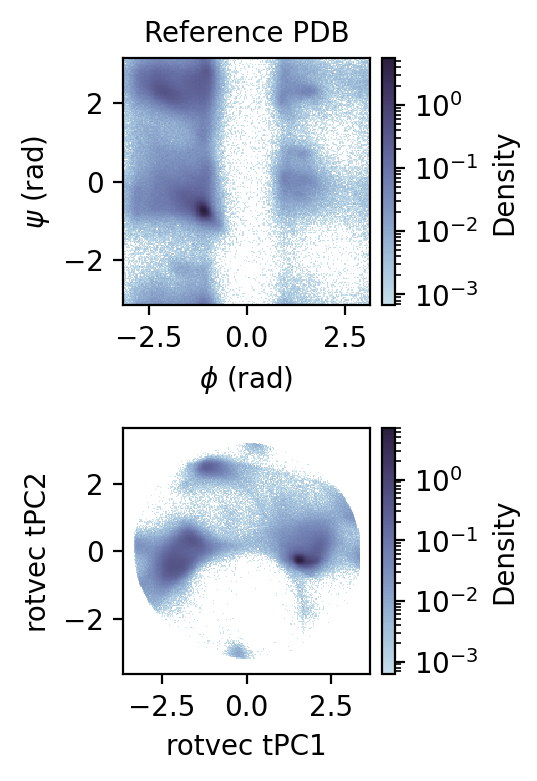

In [5]:
bin_nums = 200
bins_args = (np.linspace(-np.pi-.2, np.pi+.2, bin_nums), np.linspace(-np.pi-.2, np.pi+.2, bin_nums))
fig, ax = plt.subplots(figsize=(4/1.5,6/1.5), nrows=2, ncols=1, sharex=False, sharey=False, dpi=200) # 0.45

ax = ax[:, None]

rrot_tpc_H = g = ax[1, 0].hist2d(*rrot_tpc.T, bins=bins_args, cmap=cmap, density=True, norm=mpl.colors.LogNorm(), ) # seismic; norm=mpl.colors.LogNorm(), 
ax[1, 0].set_aspect('equal')
ax[1, 0].set_xlim(-np.pi-.5, np.pi+.5)
ax[1, 0].set_ylim(-np.pi-.5, np.pi+.5)
plt.colorbar(g[3], pad=0.03, ax=ax[1, 0], label='Density')
ax[1, 0].set_xlabel("rotvec tPC1")
ax[1, 0].set_ylabel("rotvec tPC2")
ax[0, 0].set_title('Reference PDB', fontsize=10)


bins_args = (np.linspace(-np.pi-.02, np.pi+.02, bin_nums), np.linspace(-np.pi-.02, np.pi+.02, bin_nums))

phi_psi_H = g = ax[0,0].hist2d(phi, psi, bins=bins_args, cmap=cmap, norm=mpl.colors.LogNorm(), density=True, ) # seismic; norm=mpl.colors.LogNorm(), 
ax[0,0].set_aspect('equal')
ax[0,0].set_xlim(-np.pi, np.pi)
ax[0,0].set_ylim(-np.pi, np.pi)
plt.colorbar(g[3], pad=0.03, ax=ax[0,0], label='Density')
ax[0,0].set_xlabel(r"$\phi$ (rad)")
ax[0,0].set_ylabel(r"$\psi$ (rad)")
#ax[0].set_title('Reference PDB')

fig.subplots_adjust(hspace=.5,wspace=.3)

plt.show()